# Visualização do dataset — TCC

Exploração do dataset Strava: resumo estatístico, impacto da normalização e gráficos exploratórios.

In [ ]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from dataset.analise import (
    carregar_dataset,
    resumo_dataset,
    tabela_resumo,
    resumo_preprocessamento,
    moda_distancia_km,
    plotar_painel_eda,
    plotar_painel_modelos,
    plotar_histograma_distancia,
    plotar_distribuicao_tipo_treino,
    plotar_pace_por_genero,
)
from dataset.constants import COL_ATHLETE
from dataset.preprocessamento import preprocessar

## Carregar e preprocessar dados

In [2]:
df_raw = carregar_dataset(root / "dataset/raw-data-kaggle.csv")
df = preprocessar(df_raw)

## Resumo estatístico

In [3]:
tabela_resumo(df)

registros,atletas,distancia_km_media,distancia_km_mediana,pace_mediano,fc_mediana,moda_distancia_km,moda_distancia_qtd
i64,i64,f64,f64,f64,f64,f64,i64
40534,114,11.25,10.23,5.61,148.3,10.0,4719


In [4]:
moda_km, moda_qtd = moda_distancia_km(df)
print(f"Moda de distância: {moda_km} km ({moda_qtd} corridas)")

print("\nAmostra dos dados:")
df.head()

Moda de distância: 10.0 km (4719 corridas)

Amostra dos dados:


athlete,gender,timestamp,distance (m),elapsed time (s),elevation gain (m),average heart rate (bpm),pace_min_km,tipo_treino
i64,str,str,f64,f64,f64,f64,f64,str
18042525,"""M""","""15/12/2019 09:08""",2965.8,812.0,17.4,150.3,4.563131,"""intervalado"""
18042525,"""M""","""10/12/2019 19:27""",10020.8,3290.0,52.2,160.8,5.471952,"""leve"""
18042525,"""M""","""03/12/2019 19:46""",12132.2,4027.0,249.0,148.9,5.53211,"""ritmo"""
18042525,"""M""","""26/11/2019 19:46""",11631.5,4442.0,194.0,136.2,6.3649,"""leve"""
18042525,"""M""","""19/11/2019 19:45""",11708.1,4022.0,250.7,146.0,5.725381,"""ritmo"""


In [5]:
df.describe()

statistic,athlete,gender,timestamp,distance (m),elapsed time (s),elevation gain (m),average heart rate (bpm),pace_min_km,tipo_treino
str,f64,str,str,f64,f64,f64,f64,f64,str
"""count""",40534.0,"""40534""","""40534""",40534.0,40534.0,40534.0,40534.0,40534.0,"""40534"""
"""null_count""",0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,"""0"""
"""mean""",1.5085e7,null,null,11250.671476,4149.415972,243.059059,148.254473,5.994273,null
"""std""",8.6687e6,null,null,7277.805931,3745.585549,449.954804,12.032787,1.655349,null
"""min""",771514.0,"""F""","""01/01/2010 00:00""",1000.5,143.0,0.0,41.3,2.005533,"""intervalado"""
"""25%""",6.583234e6,null,null,7472.8,2542.0,34.0,146.5,5.057686,null
"""50%""",1.3881863e7,null,null,10227.0,3460.0,88.1,148.3,5.611102,null
"""75%""",2.1299972e7,null,null,13340.4,4589.0,241.3,150.6,6.308922,null
"""max""",4.5799771e7,"""M""","""31/12/2019 17:40""",218950.0,126467.0,12078.5,219.0,14.99093,"""ritmo"""


## Impacto da normalização

In [6]:
resumo_preprocessamento(df_raw, df)

etapa,registros
str,i64
"""Dataset bruto""",42116
"""Após normalização""",40534
"""Registros removidos""",1582


## Painel exploratório (6 gráficos)

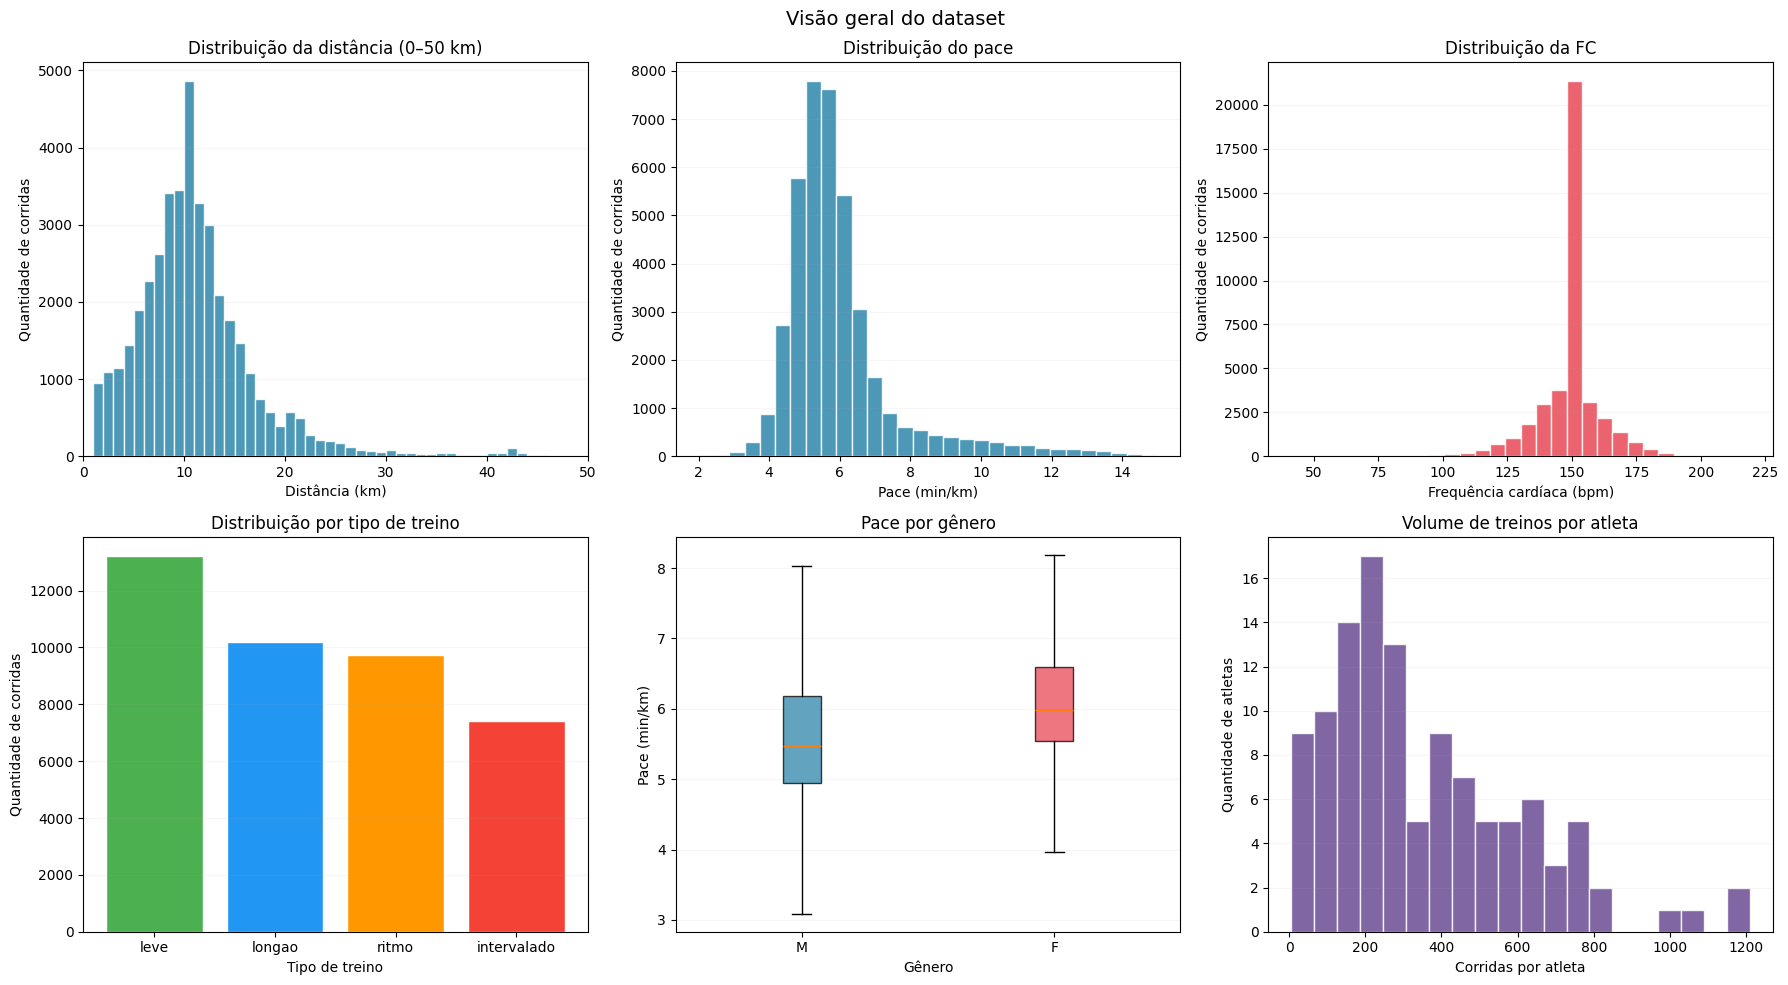

In [7]:
plotar_painel_eda(df)
plt.show()

## Relações usadas nos modelos

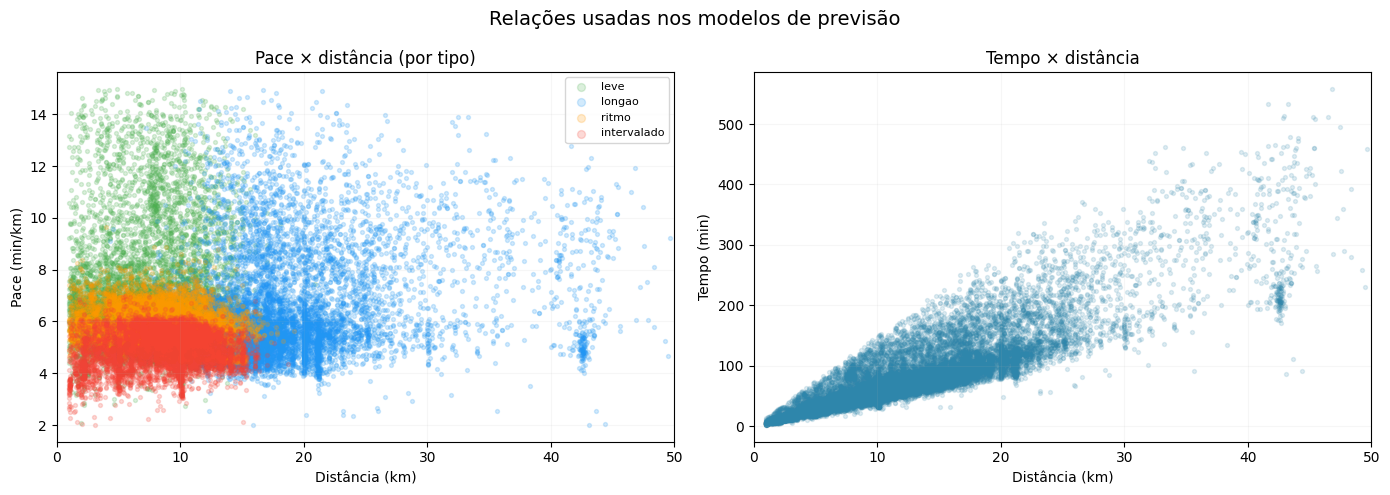

In [8]:
plotar_painel_modelos(df)
plt.show()

## Gráficos individuais

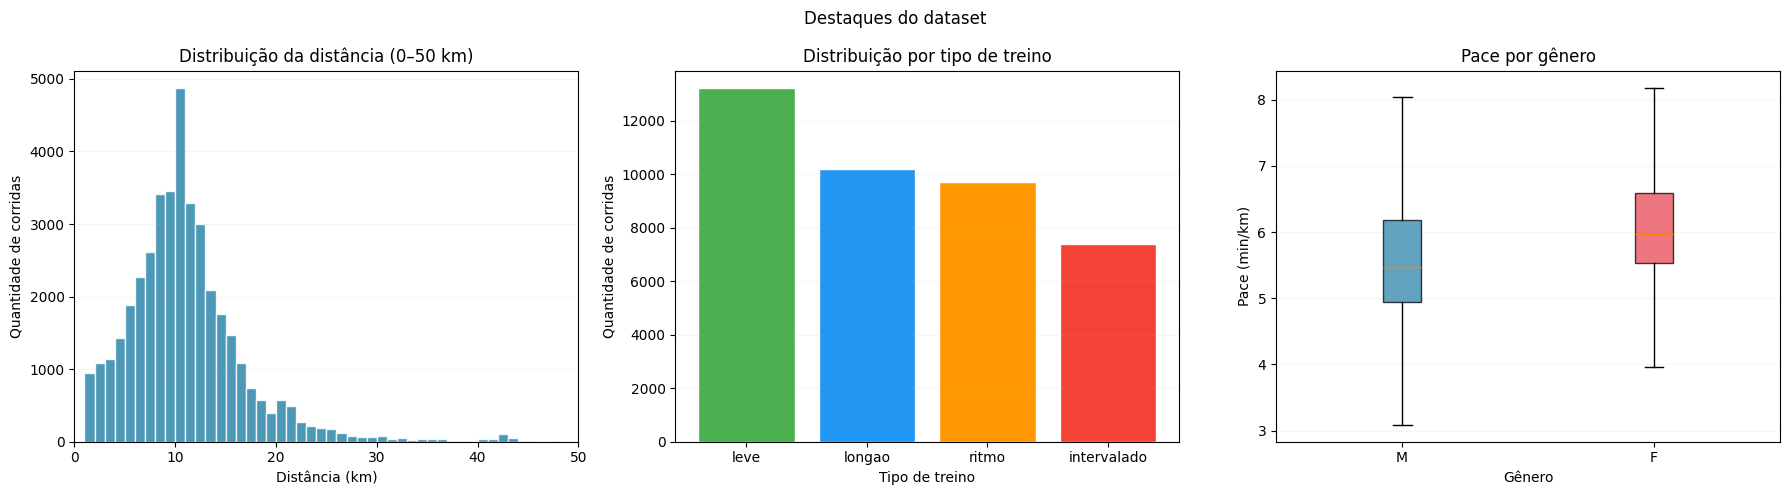

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plotar_histograma_distancia(df, ax=axes[0])
plotar_distribuicao_tipo_treino(df, ax=axes[1])
plotar_pace_por_genero(df, ax=axes[2])
fig.suptitle("Destaques do dataset")
plt.tight_layout()
plt.show()